In [27]:
 

from typing import Annotated, List, TypedDict, Literal
# from typing_extensions import TypedDict
from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.graph.message import add_messages
# from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
import os
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool



In [28]:
from dotenv import load_dotenv

load_dotenv()

import os

os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
# os.environ['LANGCHAIN_API_KEY']=os.getenv('LANGCHAIN_API_KEY')
# os.environ['LANGSMITH_TRACING_V2']="true"
# os.environ['LANGSMITH_PROJECT']="langsmithlearning"
# os.environ['LANGCHAIN_ENDPOINT']="https://api.smith.langchain.com"

In [29]:
class AgentState(MessagesState):
    next_agent:str #Which agent should go next
    

In [30]:
## Create simple tool
@tool
def search_web(query:str) -> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content:str) -> str:
    """Write a summary of the content"""
    summary = f"Summary of the findings: {content[:500]}"
    return summary


In [31]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000015EC6D8C150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015EC6D8FA50>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [32]:
## define the agent functions (simpler approach)
def researcher_agent(state:AgentState):
    """"Researcher agent that searches for infromation"""
    messages = state["messages"]

    ## add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search web tool to find the information about the user's request.")

    ## call the llm with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    ## return the response and route to the writer
    return {
        "messages": [response],
        "next_agent": "writer"
    } 

In [33]:
def writer_agent(state:AgentState):
    """Writer agent that writes a summary"""
    messages = state["messages"]

    ## Add system message for context
    system_msg = SystemMessage(content="You are a technical writer. Read the conversation and write a summary.")

    ## Simple completion without tools
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

In [34]:
## tool executer nodes
def execute_tools(state:AgentState):
    """Executes any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]

    ## check if there are tool calls to execute
    if hasattr(last_message, "tool_call") and last_message.tool_call:
        # create tool nodea and execute tool
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)

        return response

    # no tool to execute
    return state

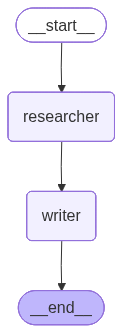

In [35]:
# build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow = workflow.compile()
final_workflow
# return workflow.compile()


In [36]:
response = final_workflow.invoke({"messages":"Research about Agentic AI usecase in business"})
response["messages"][-1].content

' \n\n**Summary:**\n\nAgentic AI refers to artificial intelligence systems that can act autonomously, making decisions and taking actions without human intervention. In a business context, Agentic AI has various use cases that can transform operational efficiency, customer experience, and revenue growth. Some of the key use cases include:\n\n1. **Automated Customer Service**: Agentic AI-powered chatbots can handle customer inquiries, provide personalized support, and resolve issues without human intervention.\n2. **Predictive Maintenance**: Agentic AI can analyze sensor data from equipment and machines, predicting when maintenance is required, reducing downtime, and increasing overall efficiency.\n3. **Supply Chain Optimization**: Agentic AI can analyze supply chain data, predict demand, and optimize inventory management, logistics, and shipping routes.\n4. **Personalized Marketing**: Agentic AI can analyze customer data, behavior, and preferences, creating personalized marketing campa

## Superwise multi AI agent Architecture

In [39]:
  

from typing import Annotated, List, TypedDict, Literal, Dict
# from typing_extensions import TypedDict
from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.graph.message import add_messages
# from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
import os
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool



In [40]:
## state definition
class SupervisorState(MessagesState):
    """State for supervisor multi-agent system"""
    current_agent: str = ""
    task_assignments: Dict[str, List[str]] = {} ## track what each agent should do
    workflow_stage: str = "initial" # Store outputs from each agent
    iteration_count: int = 0 #track workflow progress
    max_iterations: int = 10
    final_output: str = ""

In [41]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [42]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [ ]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [ ]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [ ]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [ ]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

In [ ]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
    

In [ ]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

In [ ]:
response['final_report']